In [ ]:
import numpy as np # import numpy
import astropy.units as u # import astropy units
from astropy import constants as const # import astropy constants
from ReadFile import Read
 # this is so we can read the file and take the data for our calculations
import astropy.table as tbl # make a table 
from CenterOfMass import CenterOfMass # this is to import the function from the last homework
from astropy.constants import G # this is used for the gravity constant
import matplotlib
import matplotlib.pyplot as plt

In [127]:
class MassProfile:
    # Class to define mass profile which will be used to compute the circular velocity properties of a given galaxy and simulation snapshot

    def __init__(self, galaxy, Snap):
        ''' Class to calculate the galaxy's mass profile 
            
            PARAMETERS
            self: allows all information to be store and produce its own data
            galaxy : `str` is the galaxy name - MW,M31,M33
            snap : `int; snapshot number 0,1,2 ......
        '''
        # RECONSTRUCTION OF FILES
        #add a string of the filenumber to the value 000
        ilbl = '000' + str(Snap)
        #remove all but the last 3 digits
        ilbl = ilbl[-3:]
        self.filename = "%s_"%(galaxy) + ilbl + '.txt' # this will make it easier to input
    
        # read data in the given file using Read
        self.time, self.total, self.data = Read(self.filename)                                                                                        
        # stores the mass and positions of the particles of chosen galaxy and making the corrections for units 
        self.m = self.data['m'] * 1e10 * u.Msun
        self.x = self.data['x']  *u.kpc
        self.y = self.data['y']  *u.kpc
        self.z = self.data['z'] *u.kpc

        self.gname = galaxy # store the galaxy name
        
        # these are the velocities 
        self.vx = self.data['vx'] * u.km/u.s
        self.vy = self.data['vy']  * u.km/u.s
        self.vz = self.data['vz'] * u.km/u.s

    def MassEnclosed(self, ptype, radii):
        """ This function will compute the mass enclosed for a particular particle type within a given radius of the COM position. 
            This will help the overall mass profile.
            Inputs: self: allows all information to be store and produce its own data
            ptype : `int; 1, 2, or 3` is the type of particle (Type 1 = Dark Matter, Type 2 = Disk Stars, Type 3 = Bulge Stars)
            radii: (kpc) the array of the radii magnitude
            Outputs: MassEnc:(Msun) returns the array of the mass enclosed at each radius point
        """ 
        # COM position using disk stars to compute mass profile 
        com = CenterOfMass(self.filename,2)
        comp = com.COM_P(0.1) # using the position function with distance 0.1 kpc
        # this is the distance taken from the COM function
        x_CM = self.x - comp[0] # this is the new x
        y_CM = self.y - comp[1] # this is the new y
        z_CM = self.z - comp[2] # this is the new z
        r_CM = np.sqrt((x_CM)**2 + (y_CM)**2 + (z_CM)**2) # radius particle's vector  
        
        index = np.where(self.data['type'] == ptype) # stores the data for the particle type chosen
        new_r = r_CM[index[0]] # this is the new radius magnitude with the chosen particle type
        new_m = self.m[index[0]] # new mass with the chosen particle type
        radii = np.array(radii) * u.kpc # converting the units over
        # initializing the array so it stores all the total masses within each radius
        MassEnc = np.zeros(len(radii)) * u.Msun # making sure its converted to solar mass
        # loop the radii array to get the particles that are enclosed within the radius chosen
        for i in range(len(radii)):
            enclosed = np.where(new_r <= radii[i]) # minimizing the results to be within the chosen radius
            MassEnc[i] = np.sum(new_m[enclosed]) # calculating/storing the sum of the masses of the particles that are within the radius
        return MassEnc  # returns the mass enclosed to solar mass
    def MassEnclosedTotal(self, radii):
        """ This function will compute the mass enclosed total. (buldge, disk, halo) within the radii array of each particle type
            Inputs: self: allows all information to be store and produce its own data
            radii: (kpc) the array of the radii 
            Outputs: MassTot(Msun) returns the total array of the mass enclosed at each radius point
        """ 
        halo = self.MassEnclosed(1, radii) # this is the mass enclosed for the halo particle type
        disk = self.MassEnclosed(2, radii) # this is the mass enclosed for the disk particle type
        if self.gname == "M33": #since M33 doesnt have bulge we have to ensure it takes that into account
            bulge = np.zeros(len(radii)) * u.Msun   # setting the buldge to zero and converting to solar mass
        else:
            bulge = self.MassEnclosed(3, radii)  # and if it doesn't have the name M33 then it can be calculated as normal
        total = (halo + bulge + disk) # the total mass enclosed equation
        return total   # returns the total mass enclosed 
        
    def HernquistMass(self, r, a, Mhalo):
        """ This function will compute the mass enclosed for radii within using the theoretical profile.  
            Inputs: self: allows all information to be store and produce its own data
            r: `(kpc) this is the distance from the center  
            a: (kpc) the radius length  of the mass density's movement
            Mhalo: (solar mass) the total mass of the halo 
            Outputs: HaloMass:(Msun) returns the mass distribution 
        """ 
        x = ((Mhalo*u.Msun) * ((r*u.kpc)**2)) # this is the first part and we make unit conversions
        y = ((a*u.kpc + r*u.kpc)**2) # the second part of the equation
        Mhalo = x/y # we now divide both equations 
        return Mhalo  # this is the hernquist mass in solar mass units 
    def CircularVelocity(self, ptype, radii):
        """ This function will compute the mass enclosed of each radius circular velocity with spherical symmetry
            Inputs: self: allows all information to be store and produce its own data
            ptype : `int; 1, 2, or 3` is the type of particle (Type 1 = Dark Matter, Type 2 = Disk Stars, Type 3 = Bulge Stars)
            radii: (kpc) the array of the radii magnitude
            Outputs: CircV:(km/s) rounded 2 decimal places - this is the circular velocity of the radius within the particle type
        """ 
        G1 = G.to(u.kpc * ((u.km**2) / (u.s**2)) / u.Msun)# gravitational constant converted to correct units 
        radii = np.array(radii) * u.kpc # making sure the units are properly set up
        M = self.MassEnclosed(ptype,radii) # the Mass enclosed for within chosen radiii
        Vc = np.sqrt((G1*M)/radii) # the equation put together
        CircV = np.round(Vc,2) # round the final equation
        return CircV  # the ciruclar velocity of the enclosed mass rounded  
    def CircularVelocityTotal(self, radii):
        """ This function will compute the total circular velocity of the enclosed mass within the radii. Using distribuations of bulge, disk, halo
            Inputs: self: allows all information to be store and produce its own data
            radii: (kpc) the array of the radii magnitude
            Outputs: TotCV:(km/s) the total circular velocity array using all galaxy components within the radius array
        """ 
        G3 = G.to(u.kpc * ((u.km**2) / (u.s**2)) / u.Msun)# gravitational constant converted to correct units 
        radii = radii * u.kpc # making sure the units are properly set up
        Mtot = self.MassEnclosedTotal(radii) # the Mass enclosed total for within chosen radiii
        TotC  = np.sqrt((G3*Mtot)/radii) # the equation put together
        TotCV = np.round(TotC,2) # round the final equation
        return TotCV  # the ciruclar velocity of the enclosed mass rounded  
    def HernquistVCirc(self, r, a, Mhalo):
        """ This function will compute the circular speed using the hernquist mass profile   
            Inputs: self: allows all information to be store and produce its own data
            r: `(kpc) this is the distance from the center  
            a: (kpc) the radius length  of the mass density's movement
            Mhalo: (solar mass) the total mass of the halo 
            Outputs: HVC:(km/s) returns the circular speed rounded to 2 decimal places of each radius mass profile
        """ 
        G2 = G.to(u.kpc * ((u.km**2) / (u.s**2)) / u.Msun) # gravitational constant converted to correct units 
        r = np.array(r)* u.kpc # making sure the units are properly set up
        a = a * u.kpc # converting the radial length to correct units 
        M4 = self.HernquistMass(r, a, Mhalo) # the Mass enclosed for radius using the hernquist function
        Vc2 = np.sqrt((G2*M4)/(r)) # the equation put together
        HVC = np.round(Vc2,2) # round the final equation
        return HVC  # the circular speed of the enclosed mass rounded  

    def plot(self):
        """ This function will be used to make plots for each galaxy with a radius of 30 kpc. Mass enclosed for bulge,halo, disk
            Sum of all components using massenclosed total and the best fitting hernquist profile
        """
        # this is the radii array used for all plots in this section from 0.1 to 33 kpc
        radii = np.arange(0.1, 33, 1.65)
        print(radii) #print the radii
        Phalo = self.MassEnclosed(1,radii) # this is the mass enclosed for the halo particle type
        Pdisk = self.MassEnclosed(2,radii) # this is the mass enclosed for the disk particle type
        if self.gname == "M33": #since M33 doesnt have bulge we have to ensure it takes that into account
            bulgeP = np.zeros(len(radii))  # setting the buldge to zero 
        else:
            bulgeP = self.MassEnclosed(3, radii) # regular bulge if its not M33
        TotME = self.MassEnclosedTotal(radii) # this is the total mass enclosed using the mass enclosed total
        Mhalo = np.max(TotME) # mass halo is the max of the total mass enclosed to get the best fit herquist profile
        a = 12.75 # the radius length being adjusted for each plot separately 
        HernP= self.HernquistMass(radii, a, Mhalo) # final equation to determine the herquist mass 
        
        fig = plt.figure(figsize=(10,10))  # sets the scale of the figure
        ax = plt.subplot(111) 
        # Plot the  values (x axis log) for each type of galaxy and tot enclosed mass and best fit hernquist profile
        ax.semilogy(radii, Phalo, color='blue', linewidth=5, linestyle='solid', label='Halo')
        ax.semilogy(radii, Pdisk, color='red', linewidth=5,linestyle=':', label='Disk')
        ax.semilogy(radii, bulgeP, color='black', linewidth=5,linestyle='--', label='Bulge')
        ax.semilogy(radii, TotME, color='green', linewidth=5,linestyle='dashdot', label='Total Enclosed Mass')
        ax.semilogy(radii, HernP, color='pink', linewidth=5,linestyle='dotted', label='Best-Fit Hernquist Profile')

        # Add labels
        plt.xlabel("Radius (kpc)", fontsize=22)
        plt.ylabel("Mass Enclosed (Solar Mass)", fontsize=22)
        plt.title(f"Mass Profile for Galaxy {self.gname}",fontsize=22)
        #set axis limits
        plt.xlim(0,35)
        # yaxis is in log 
        plt.semilogy()

        #adjust tick label font size
        label_size = 22
        matplotlib.rcParams['xtick.labelsize'] = label_size 
        matplotlib.rcParams['ytick.labelsize'] = label_size

        # add a legend  
        legend = ax.legend(loc='upper right',fontsize='x-large')

        # Save to image 
        plt.savefig(f"{self.gname}_MassProfile.png")
        plt.show() # show the plot

    def plot2(self):
        """ This function will be used to make rotational curve plots for each galaxy with a radius of 30 kpc. Using the 
            circular speed function of each galaxy- circular velocity, total circular velocity, hernquist circular velocity
        """
        # this is the radii array used for all plots in this section from 0.1 to 33 kpc
        radii = np.arange(0.1, 33, 1.65)
        print(radii) # prints the radii
        Rhalo = self.CircularVelocity(1,radii) # this is the velocity for the halo particle type
        Rdisk = self.CircularVelocity(2,radii) # this is the velocity for the disk particle type
        if self.gname == "M33": #since M33 doesnt have bulge we have to ensure it takes that into account
            bulgeR = np.zeros(len(radii)) # setting the buldge to zero 
        else:
            bulgeR = self.CircularVelocity(3, radii)
        TotCS = self.CircularVelocityTotal(radii) # the total circular velocity
        Mhalo = np.max(self.MassEnclosed(1,radii)) # the max value the Mhalo for the herquist profile will be used used mass enclosed
        a = 11.04 # this is the radial length being adjusted for each plot separately 
        HernV= self.HernquistVCirc(radii, a, Mhalo) # the final equation for the hernquist circular velocity

        fig = plt.figure(figsize=(10,10))  # sets the scale of the figure
        ax = plt.subplot(111) 

        # Plot the  values (x axis log) or each type of galaxy and tot circular speed and best fit hernquist profile circular speed
        ax.semilogy(radii, Rhalo, color='blue', linewidth=5, linestyle='solid', label='Halo')
        ax.semilogy(radii, Rdisk, color='red', linewidth=5,linestyle=':', label='Disk')
        ax.semilogy(radii, bulgeR, color='black', linewidth=5,linestyle='--', label='Bulge')
        ax.semilogy(radii, TotCS, color='green', linewidth=5,linestyle='dashdot', label='Total Circular Speed')
        ax.semilogy(radii, HernV, color='pink', linewidth=5,linestyle='dotted', label='Best-Fit Hernquist Circular Speed')
         # Add labels
        plt.xlabel("Radius (kpc)", fontsize=22)
        plt.ylabel("Circular Velocity(km/s)", fontsize=22)
        plt.title(f"Rotation Curve for Galaxy {self.gname}",fontsize=22)
        #set axis limits
        plt.xlim(0,30)
         #setting the max y value
        plt.semilogy() # yaxis is in log 
    
        #adjust tick label font size
        label_size = 22
        matplotlib.rcParams['xtick.labelsize'] = label_size 
        matplotlib.rcParams['ytick.labelsize'] = label_size

        # add a legend  
        ax.legend(loc='upper right',fontsize='x-large')

        # Save as a image 
        plt.savefig(f"{self.gname}_RotationCurve.png")
        plt.show() # show the plot
    

In [128]:
      def MassEnclosed(self, ptype, radii):
        """ This function will compute the mass enclosed for a particular particle type within a given radius of the COM position. 
            This will help the overall mass profile.
            Inputs: self: allows all information to be store and produce its own data
            ptype : `int; 1, 2, or 3` is the type of particle (Type 1 = Dark Matter, Type 2 = Disk Stars, Type 3 = Bulge Stars)
            radii: (kpc) the array of the radii magnitude
            Outputs: MassEnc:(Msun) returns the array of the mass enclosed at each radius point
        """ 
        # COM position using disk stars to compute mass profile 
        com = CenterOfMass(self.filename,2)
        comp = com.COM_P(0.1) # using the position function with distance 0.1 kpc
        # this is the distance taken from the COM function
        x_CM = self.x - comp[0] # this is the new x
        y_CM = self.y - comp[1] # this is the new y
        z_CM = self.z - comp[2] # this is the new z
        r_CM = np.sqrt((x_CM)**2 + (y_CM)**2 + (z_CM)**2) # radius particle's vector  
        
        index = np.where(self.data['type'] == ptype) # stores the data for the particle type chosen
        new_r = r_CM[index[0]] # this is the new radius magnitude with the chosen particle type
        new_m = self.m[index[0]] # new mass with the chosen particle type
        radii = np.array(radii) * u.kpc # converting the units over
        # initializing the array so it stores all the total masses within each radius
        MassEnc = np.zeros(len(radii)) * u.Msun # making sure its converted to solar mass
        # loop the radii array to get the particles that are enclosed within the radius chosen
        for i in range(len(radii)):
            enclosed = np.where(new_r <= radii[i]) # minimizing the results to be within the chosen radius
            MassEnc[i] = np.sum(new_m[enclosed]) # calculating/storing the sum of the masses of the particles that are within the radius
        return MassEnc  # returns the mass enclosed to solar mass

In [129]:
#test
#MW = MassProfile("MW",0)
#r= [ 0.1   1.75  3.4   5.05  6.7   8.35 10.   11.65 13.3  14.95 16.6  18.25]
#MW.MassEnclosed(1,r)

In [130]:
    def MassEnclosedTotal(self, radii):
        """ This function will compute the mass enclosed total. (buldge, disk, halo) within the radii array of each particle type
            Inputs: self: allows all information to be store and produce its own data
            radii: (kpc) the array of the radii 
            Outputs: MassTot(Msun) returns the total array of the mass enclosed at each radius point
        """ 
        halo = self.MassEnclosed(1, radii) # this is the mass enclosed for the halo particle type
        disk = self.MassEnclosed(2, radii) # this is the mass enclosed for the disk particle type
        if self.gname == "M33": #since M33 doesnt have bulge we have to ensure it takes that into account
            bulge = np.zeros(len(radii)) * u.Msun   # setting the buldge to zero and converting to solar mass
        else:
            bulge = self.MassEnclosed(3, radii)  # and if it doesn't have the name M33 then it can be calculated as normal
        total = (halo + bulge + disk) # the total mass enclosed equation
        return total   # returns the total mass enclosed 

In [131]:
    def HernquistMass(self, r, a, Mhalo):
        """ This function will compute the mass enclosed for radii within using the theoretical profile.  
            Inputs: self: allows all information to be store and produce its own data
            r: `(kpc) this is the distance from the center  
            a: (kpc) the radius length  of the mass density's movement
            Mhalo: (solar mass) the total mass of the halo 
            Outputs: HaloMass:(Msun) returns the mass distribution 
        """ 
        x = ((Mhalo*u.Msun) * ((r*u.kpc)**2)) # this is the first part and we make unit conversions
        y = ((a*u.kpc + r*u.kpc)**2) # the second part of the equation
        Mhalo = x/y # we now divide both equations 
        return Mhalo  # this is the hernquist mass in solar mass units 

In [132]:
    def CircularVelocity(self, ptype, radii):
        """ This function will compute the mass enclosed of each radius circular velocity with spherical symmetry
            Inputs: self: allows all information to be store and produce its own data
            ptype : `int; 1, 2, or 3` is the type of particle (Type 1 = Dark Matter, Type 2 = Disk Stars, Type 3 = Bulge Stars)
            radii: (kpc) the array of the radii magnitude
            Outputs: CircV:(km/s) rounded 2 decimal places - this is the circular velocity of the radius within the particle type
        """ 
        G1 = G.to(u.kpc * ((u.km**2) / (u.s**2)) / u.Msun)# gravitational constant converted to correct units 
        radii = np.array(radii) * u.kpc # making sure the units are properly set up
        M = self.MassEnclosed(ptype,radii) # the Mass enclosed for within chosen radiii
        Vc = np.sqrt((G1*M)/radii) # the equation put together
        CircV = np.round(Vc,2) # round the final equation
        return CircV  # the ciruclar velocity of the enclosed mass rounded  

In [133]:
    def CircularVelocityTotal(self, radii):
        """ This function will compute the total circular velocity of the enclosed mass within the radii. Using distribuations of bulge, disk, halo
            Inputs: self: allows all information to be store and produce its own data
            radii: (kpc) the array of the radii magnitude
            Outputs: TotCV:(km/s) the total circular velocity array using all galaxy components within the radius array
        """ 
        G3 = G.to(u.kpc * ((u.km**2) / (u.s**2)) / u.Msun)# gravitational constant converted to correct units 
        radii = radii * u.kpc # making sure the units are properly set up
        Mtot = self.MassEnclosedTotal(radii) # the Mass enclosed total for within chosen radiii
        TotC  = np.sqrt((G3*Mtot)/radii) # the equation put together
        TotCV = np.round(TotC,2) # round the final equation
        return TotCV  # the ciruclar velocity of the enclosed mass rounded  

In [134]:
    def HernquistVCirc(self, r, a, Mhalo):
        """ This function will compute the circular speed using the hernquist mass profile   
            Inputs: self: allows all information to be store and produce its own data
            r: `(kpc) this is the distance from the center  
            a: (kpc) the radius length  of the mass density's movement
            Mhalo: (solar mass) the total mass of the halo 
            Outputs: HVC:(km/s) returns the circular speed rounded to 2 decimal places of each radius mass profile
        """ 
        G2 = G.to(u.kpc * ((u.km**2) / (u.s**2)) / u.Msun) # gravitational constant converted to correct units 
        r = np.array(r)* u.kpc # making sure the units are properly set up
        a = a * u.kpc # converting the radial length to correct units 
        M4 = self.HernquistMass(r, a, Mhalo) # the Mass enclosed for radius using the hernquist function
        Vc2 = np.sqrt((G2*M4)/(r)) # the equation put together
        HVC = np.round(Vc2,2) # round the final equation
        return HVC  # the circular speed of the enclosed mass rounded  

In [135]:
# making the plots 
# used different online resources to make the plots: https://python4astronomers.github.io/plotting/matplotlib.html, google AI, stack overflow, openAstronomy
    def plot(self):
        """ This function will be used to make plots for each galaxy with a radius of 30 kpc. Mass enclosed for bulge,halo, disk
            Sum of all components using massenclosed total and the best fitting hernquist profile
        """
        # this is the radii array used for all plots in this section from 0.1 to 33 kpc
        radii = np.arange(0.1, 33, 1.65)
        print(radii) #print the radii
        Phalo = self.MassEnclosed(1,radii) # this is the mass enclosed for the halo particle type
        Pdisk = self.MassEnclosed(2,radii) # this is the mass enclosed for the disk particle type
        if self.gname == "M33": #since M33 doesnt have bulge we have to ensure it takes that into account
            bulgeP = np.zeros(len(radii))  # setting the buldge to zero 
        else:
            bulgeP = self.MassEnclosed(3, radii) # regular bulge if its not M33
        TotME = self.MassEnclosedTotal(radii) # this is the total mass enclosed using the mass enclosed total
        Mhalo = np.max(TotME) # mass halo is the max of the total mass enclosed to get the best fit herquist profile
        a =  22 # the radius length being adjusted for each plot separately 
        HernP= self.HernquistMass(radii, a, Mhalo) # final equation to determine the herquist mass 
        
        fig = plt.figure(figsize=(10,10))  # sets the scale of the figure
        ax = plt.subplot(111) 
        # Plot the  values (x axis log) for each type of galaxy and tot enclosed mass and best fit hernquist profile
        ax.semilogy(radii, Phalo, color='blue', linewidth=5, linestyle='solid', label='Halo')
        ax.semilogy(radii, Pdisk, color='red', linewidth=5,linestyle=':', label='Disk')
        ax.semilogy(radii, bulgeP, color='black', linewidth=5,linestyle='--', label='Bulge')
        ax.semilogy(radii, TotME, color='green', linewidth=5,linestyle='dashdot', label='Total Enclosed Mass')
        ax.semilogy(radii, HernP, color='pink', linewidth=5,linestyle='dotted', label='Best-Fit Hernquist Profile')

        # Add labels
        plt.xlabel("Radius (kpc)", fontsize=22)
        plt.ylabel("Mass Enclosed (Solar Mass)", fontsize=22)
        plt.title(f"Mass Profile for Galaxy {self.gname}",fontsize=22)
        #set axis limits
        plt.xlim(0,35)
        # yaxis is in log 
        plt.semilogy()

        #adjust tick label font size
        label_size = 22
        matplotlib.rcParams['xtick.labelsize'] = label_size 
        matplotlib.rcParams['ytick.labelsize'] = label_size

        # add a legend  
        legend = ax.legend(loc='upper right',fontsize='x-large')

        # Save to image 
        plt.savefig(f"{self.gname}_MassProfile.png")
        plt.show() # show the plot

IndentationError: unexpected indent (1776706425.py, line 3)

[ 0.1   1.75  3.4   5.05  6.7   8.35 10.   11.65 13.3  14.95 16.6  18.25
 19.9  21.55 23.2  24.85 26.5  28.15 29.8  31.45]


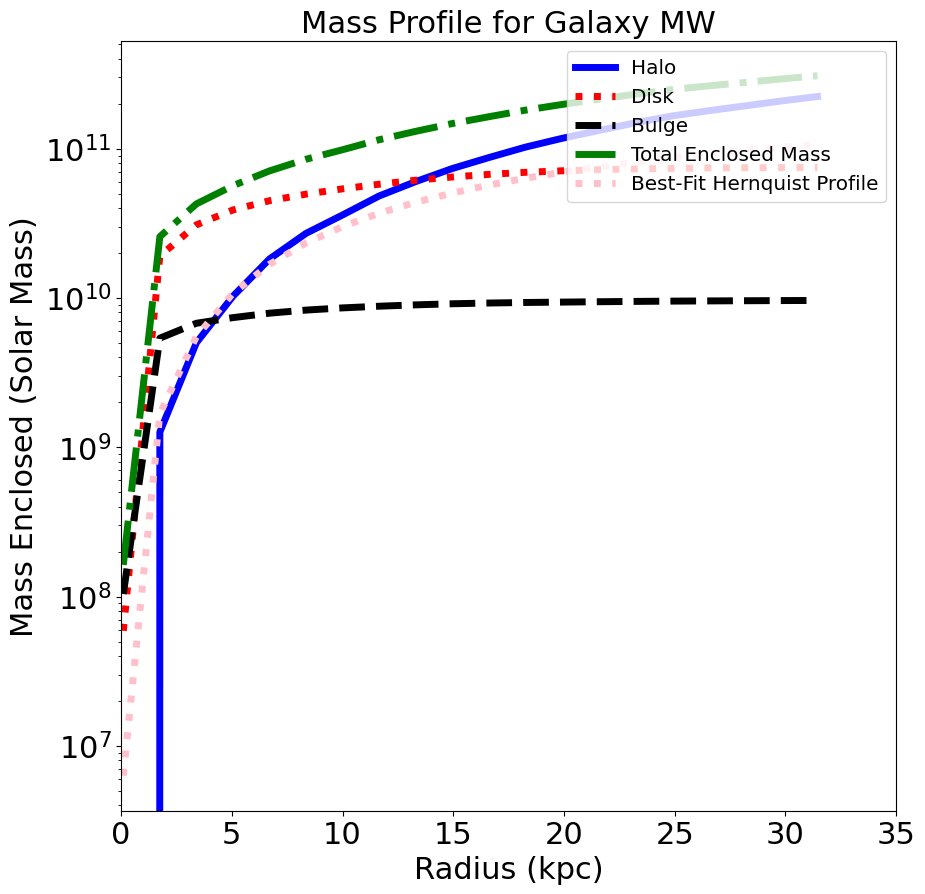

In [76]:
# MW Mass Profile   a = 22
MW = MassProfile("MW",0)
MW.plot()

[ 0.1   1.75  3.4   5.05  6.7   8.35 10.   11.65 13.3  14.95 16.6  18.25
 19.9  21.55 23.2  24.85 26.5  28.15 29.8  31.45]


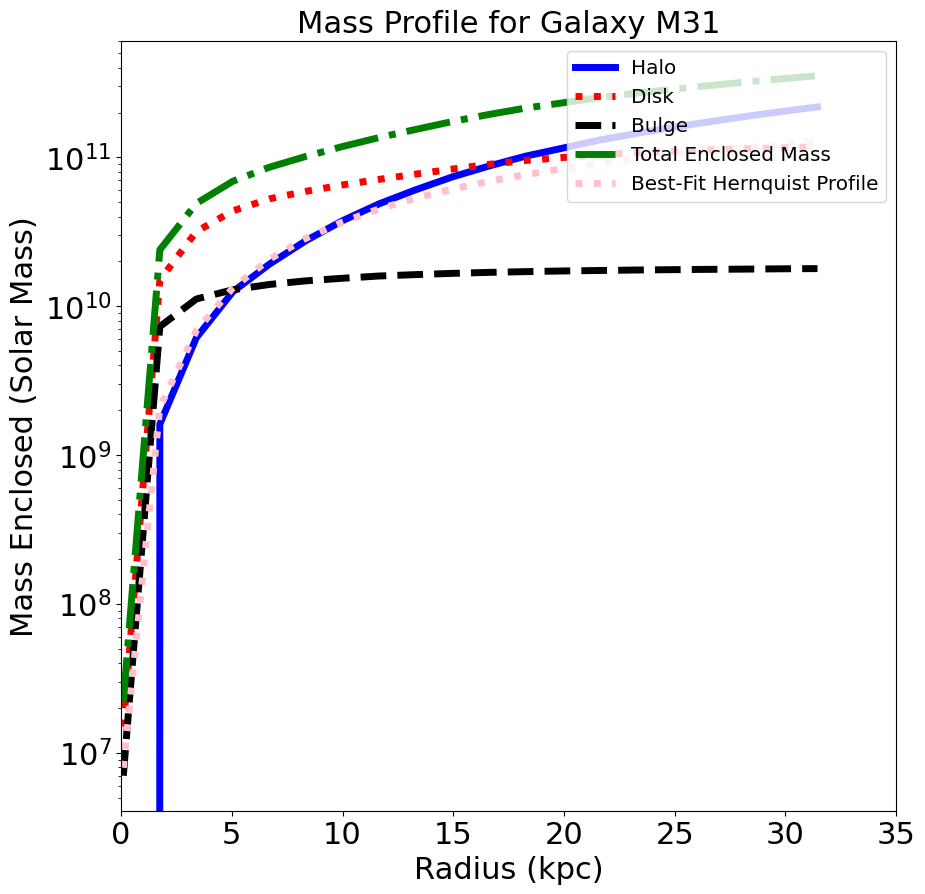

In [70]:
# M31 Mass profile a = 21
M31 = MassProfile("M31",0)
M31.plot()

[ 0.1   1.75  3.4   5.05  6.7   8.35 10.   11.65 13.3  14.95 16.6  18.25
 19.9  21.55 23.2  24.85 26.5  28.15 29.8  31.45]


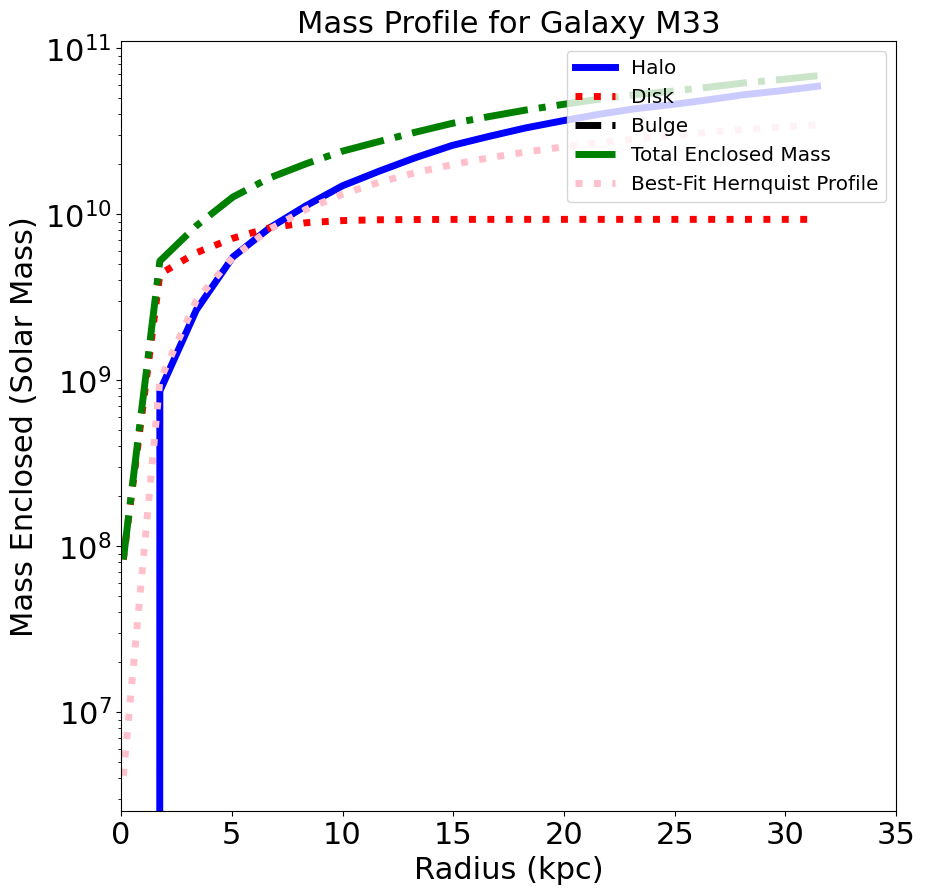

In [83]:
# M33 Mass Profile a = 12.75
M33 = MassProfile("M33",0)
M33.plot()

In [136]:
# making the plots 
# used different online resources to make the plots: https://python4astronomers.github.io/plotting/matplotlib.html, google AI, stack overflow, openAstronomy
    def plot2(self):
        """ This function will be used to make rotational curve plots for each galaxy with a radius of 30 kpc. Using the 
            circular speed function of each galaxy- circular velocity, total circular velocity, hernquist circular velocity
        """
        # this is the radii array used for all plots in this section from 0.1 to 33 kpc
        radii = np.arange(0.1, 33, 1.65)
        print(radii) # prints the radii
        Rhalo = self.CircularVelocity(1,radii) # this is the velocity for the halo particle type
        Rdisk = self.CircularVelocity(2,radii) # this is the velocity for the disk particle type
        if self.gname == "M33": #since M33 doesnt have bulge we have to ensure it takes that into account
            bulgeR = np.zeros(len(radii)) # setting the buldge to zero 
        else:
            bulgeR = self.CircularVelocity(3, radii)
        TotCS = self.CircularVelocityTotal(radii) # the total circular velocity
        Mhalo = np.max(self.MassEnclosed(1,radii)) # the max value the Mhalo for the herquist profile will be used used mass enclosed
        a = 11.04  # this is the radial length being adjusted for each plot separately 
        HernV= self.HernquistVCirc(radii, a, Mhalo) # the final equation for the hernquist circular velocity

        fig = plt.figure(figsize=(10,10))  # sets the scale of the figure
        ax = plt.subplot(111) 

        # Plot the  values (x axis log) or each type of galaxy and tot circular speed and best fit hernquist profile circular speed
        ax.semilogy(radii, Rhalo, color='blue', linewidth=5, linestyle='solid', label='Halo')
        ax.semilogy(radii, Rdisk, color='red', linewidth=5,linestyle=':', label='Disk')
        ax.semilogy(radii, bulgeR, color='black', linewidth=5,linestyle='--', label='Bulge')
        ax.semilogy(radii, TotCS, color='green', linewidth=5,linestyle='dashdot', label='Total Circular Speed')
        ax.semilogy(radii, HernV, color='pink', linewidth=5,linestyle='dotted', label='Best-Fit Hernquist Circular Speed')
         # Add labels
        plt.xlabel("Radius (kpc)", fontsize=22)
        plt.ylabel("Circular Velocity(km/s)", fontsize=22)
        plt.title(f"Rotation Curve for Galaxy {self.gname}",fontsize=22)
        #set axis limits
        plt.xlim(0,30)
         #setting the max y value
        plt.semilogy() # yaxis is in log 
    
        #adjust tick label font size
        label_size = 22
        matplotlib.rcParams['xtick.labelsize'] = label_size 
        matplotlib.rcParams['ytick.labelsize'] = label_size

        # add a legend  
        ax.legend(loc='upper right',fontsize='x-large')

        # Save as a image 
        plt.savefig(f"{self.gname}_RotationCurve.png")
        plt.show() # show the plot

IndentationError: unexpected indent (3219346096.py, line 3)

[ 0.1   1.75  3.4   5.05  6.7   8.35 10.   11.65 13.3  14.95 16.6  18.25
 19.9  21.55 23.2  24.85 26.5  28.15 29.8  31.45]


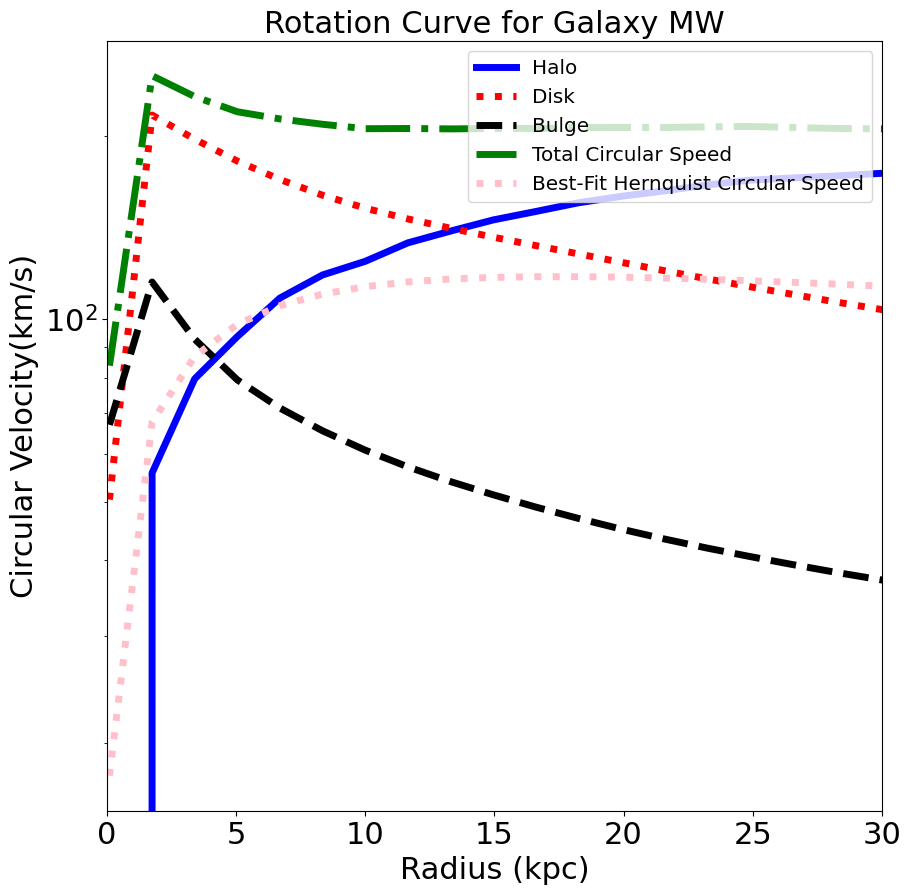

In [117]:
# MW Rotational curve   a = 17.45
MW = MassProfile("MW",0)
MW.plot2()

[ 0.1   1.75  3.4   5.05  6.7   8.35 10.   11.65 13.3  14.95 16.6  18.25
 19.9  21.55 23.2  24.85 26.5  28.15 29.8  31.45]


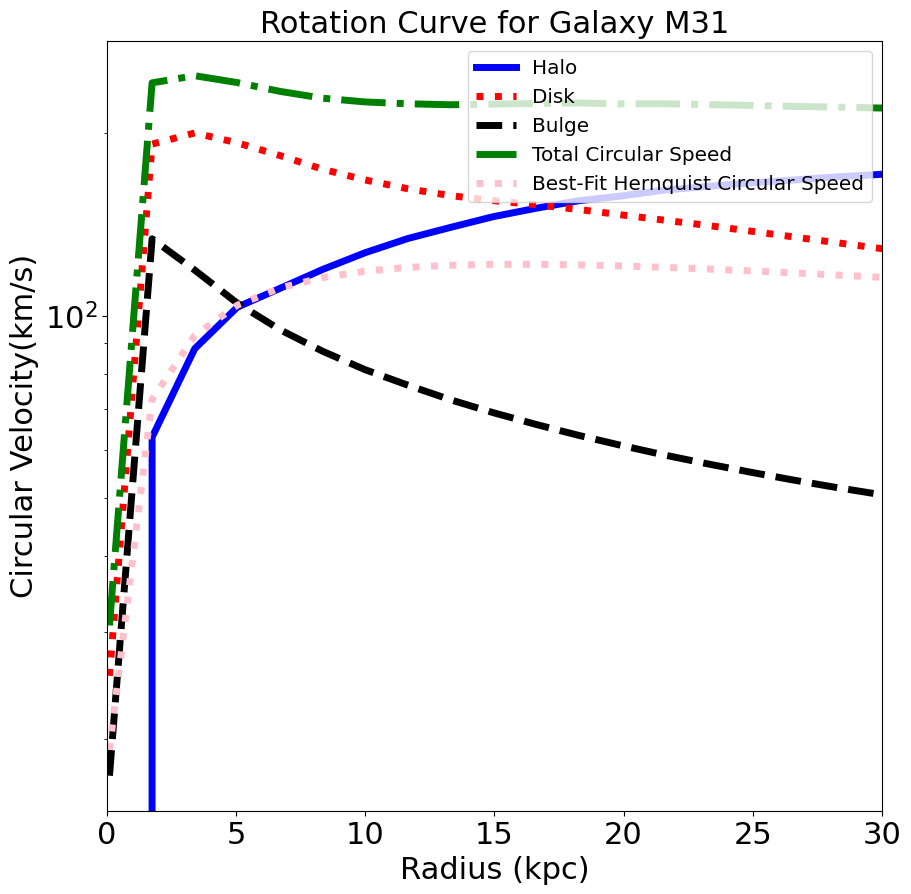

In [115]:
# M31 Rotational curve     a = 15.87 
M31 = MassProfile("M31",0)
M31.plot2()

[ 0.1   1.75  3.4   5.05  6.7   8.35 10.   11.65 13.3  14.95 16.6  18.25
 19.9  21.55 23.2  24.85 26.5  28.15 29.8  31.45]


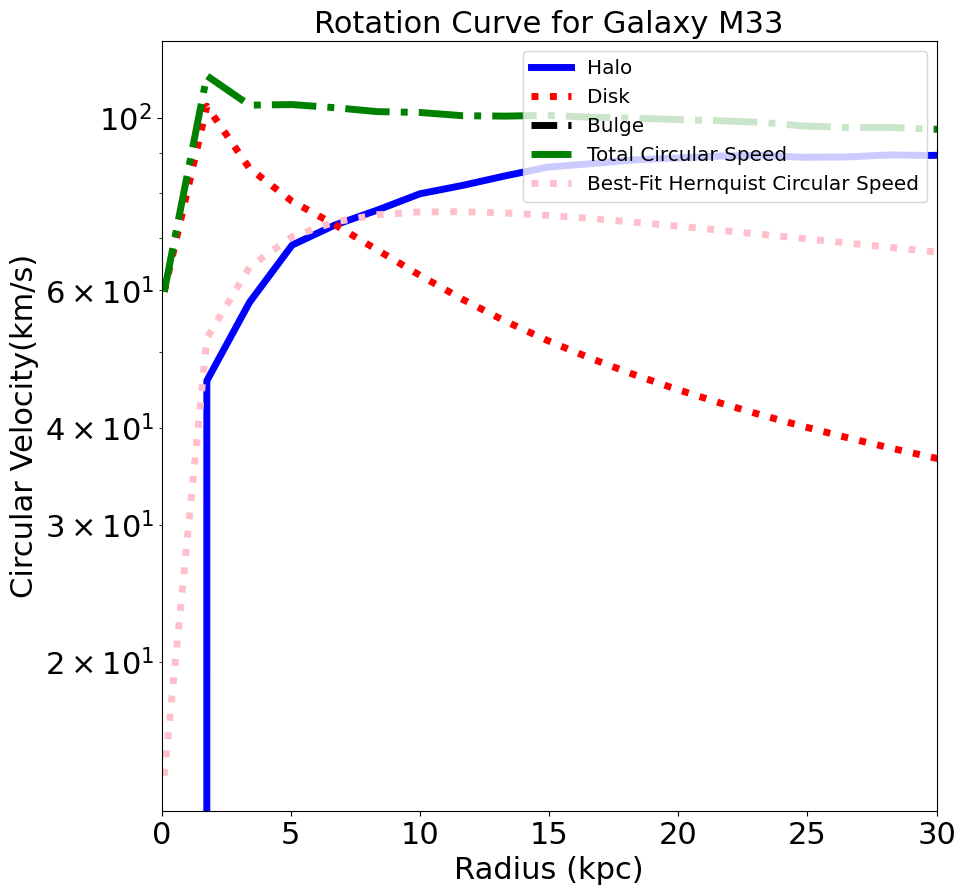

In [126]:
# M33 Rotational curve    a =  11.04
M33 = MassProfile("M33",0)
M33.plot2()